In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot
from useful_stuff.general_utils.RSA import  dRSA
from useful_stuff.general_utils.regression import  dyn_linear_encoding
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data, load_eyetracking_data
from image_processing.gaze_dep_models import save_ANN_features


In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    gaze_fs = 50
    mod_fs = 23.976
    sq_side = 384
    sensors_group = 'occ'
    model_name = "vit_l_16"
    full_model_name = "alexnet_features.4"
    time_points = 600
    pseudotrials_n = 50
    max_lag = 200
    iterations_n = 100
    repetition = 0
    RDM_metric = "correlation"
    pkg = 'timm'
    regr_out_eyes = True
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)

In [3]:
def load_ICA_meg_data(paths: dict[str: str], sub_num: int, run: int, sensors_group: str, fs: float):
    file_path = f"{paths['data_path']}/data/sub{sub_num:03d}/preprocessed_eyeICA/sub{sub_num:03d}_{sensors_group}_{fs}Hz_MNN0_badmuscle0_badlowfreq1_badsegint1_badcomp1.mat"    
    data = loadmat(file_path)
    labels = [str(x[0]) for x in data['label'].flatten()]
    data_neural = data['data_final'][run-1][0]
    data_neural = TimeSeries(data_neural, fs)
    return data_neural, labels
# EOF

In [4]:

def subsampling_II(neu_trials, mod_trials, neu_metric, mod_metric, k=1):
    drsa_obj_corr = dynInformationImbalance(neu_metric, mod_metric, k=k)
    drsa_obj_corr.compute_both_RDM_timeseries(neu_trials, mod_trials)
    drsa_obj_corr.compute_both_distance_ranks_timeseries()
    rsa_corr = drsa_obj_corr.compute_dynII('B2A')
    return rsa_corr
# EOF

def subsampling_RSA(neu_trials, mod_trials, neu_metric, mod_metric,):
    drsa_obj_corr = dRSA(neu_metric, model_RDM_metric=mod_metric)
    drsa_obj_corr.compute_both_RDM_timeseries(neu_trials, mod_trials)
    rsa_corr = drsa_obj_corr.compute_dRSA()
    return rsa_corr
# EOF

def subsampling(neu, mod, time_points, iteration_n, pseudotrials_n, func, *args, **kwargs):
    tot_rsa = np.zeros((time_points, time_points))
    for i_iter in range(iteration_n):
        if i_iter %10 ==0:
            print_wise(f"starting iteration {i_iter} of {iteration_n-1} ")
        neu_trials = []
        mod_trials = []
        pseudotrials_idx = random.sample(range(len(neu)- time_points), pseudotrials_n )
        for n in pseudotrials_idx:
            neu_trials.append(neu.get_array()[:,n:n+time_points])
            mod_trials.append(mod.get_array()[:,n:n+time_points])
        neu_trials = TimeSeries(np.stack(neu_trials, axis=2), cfg.neu_fs)
        mod_trials = TimeSeries(np.stack(mod_trials, axis=2), cfg.neu_fs)
        # drsa_obj_corr = dRSA("correlation")
        rsa_corr = func(neu_trials, mod_trials, *args, **kwargs)    
        tot_rsa += rsa_corr
    tot_rsa = tot_rsa/iteration_n
    return tot_rsa
# EOF

In [5]:
def plot_rsa(tot_rsa, neu_fs, max_lag, title=None, tick_step=20):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # --- heatmap ---
    ax[0].imshow(tot_rsa)

    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / neu_fs, 2)
    ticks += max_lag

    # --- lag plot ---
    lagplot = get_lagplot(tot_rsa, max_lag=max_lag)
    ax[1].plot(lagplot)

    ax[1].set_ylabel("dRSA similarity")
    ax[1].set_xlabel("lag [sec]")
    ax[1].set_xticks(ticks, ticks_labels)
    ax[1].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)

    # --- 🔥 compute peak ---
    peak_idx = np.argmax(lagplot)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / neu_fs  # convert to seconds

    # --- 🔥 textbox ---
    textstr = f"peak: {peak_val:.3f}\nlag: {peak_lag:.2f}s"
    ax[1].text(
        0.05, 0.95, textstr,
        transform=ax[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    # --- labels ---
    ax[0].set_xlabel(f"Model time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_ylabel(f"Neural time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()


# def plot_rsa(tot_rsa, neu_fs, max_lag, title=None, tick_step=20):
#     fig, ax = plt.subplots(1, 2, figsize=(10, 4))

#     # --- heatmap ---
#     ax[0].imshow(tot_rsa)

#     ticks = np.arange(-max_lag, max_lag + 1, tick_step)
#     ticks_labels = np.round(ticks / neu_fs, 2)
#     ticks += max_lag

#     # --- lag plot ---
#     lagplot = get_lagplot(tot_rsa, max_lag=max_lag)
#     ax[1].plot(lagplot)

#     ax[1].set_ylabel("dRSA similarity")
#     ax[1].set_xlabel("lag [sec]")
#     ax[1].set_xticks(ticks, ticks_labels)
#     ax[1].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)

#     # --- 🔥 compute centroid ---
#     lags = np.arange(-max_lag, max_lag + 1)

#     weights = lagplot.copy()
#     weights[weights < 0] = 0  # ignore negative values

#     if np.sum(weights) > 0:
#         centroid_idx = np.sum(lags * weights) / np.sum(weights)
#     else:
#         centroid_idx = np.nan

#     centroid_lag = centroid_idx / neu_fs  # convert to seconds

#     # --- 🔥 textbox ---
#     textstr = f"centroid: {centroid_lag:.2f}s"
#     ax[1].text(
#         0.05, 0.95, textstr,
#         transform=ax[1].transAxes,
#         fontsize=10,
#         verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
#     )

#     # --- (optional) visualize centroid ---
#     if not np.isnan(centroid_idx):
#         ax[1].axvline(centroid_idx + max_lag, linestyle="--")

#     # --- labels ---
#     ax[0].set_xlabel(f"Model time, length={tot_rsa.shape[1]/neu_fs}sec")
#     ax[0].set_ylabel(f"Neural time, length={tot_rsa.shape[1]/neu_fs}sec")
#     ax[0].set_xticks([])
#     ax[0].set_yticks([])

#     fig.suptitle(title, fontsize=20)
#     plt.tight_layout()

In [6]:
mod = []
len_mod = []
for i_run in range(1,4):
    model_filename = save_ANN_features(paths, cfg.full_model_name, cfg.mod_fs, cfg.sub_num, i_run + 3*cfg.repetition, 1000, cfg.sq_side, 'all')
    with h5py.File(model_filename, "r") as f:
        run_mod = f['vecrep'][:]
    # end with h5py.File(model_filename, "r") as f:
    run_mod = TimeSeries(run_mod, cfg.mod_fs)
    run_mod.resample(cfg.neu_fs)
    len_mod.append(len(run_mod)) 
    mod.append(run_mod.get_array())
# end for i_run in range(1,4):
mod = TimeSeries(np.concatenate(mod, axis=1), cfg.neu_fs)


ValueError: Unknown format code 'd' for object of type 'float'

In [11]:
neu = []
mod = []
len_mod = []
print(f"Regressing out eyes: {cfg.regr_out_eyes}")
for i_run in range(1,4):
    run_neu, labels = load_ICA_meg_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.sensors_group, cfg.neu_fs)
    run_neu.z_score_feats()
    model_filename = save_ANN_features(paths, cfg.full_model_name, cfg.sub_num, i_run + 3*cfg.repetition, cfg.mod_fs, cfg.sq_side, 1000,  'all')
    with h5py.File(model_filename, "r") as f:
        run_mod = f['vecrep'][:]
    # end with h5py.File(model_filename, "r") as f:
    run_mod = TimeSeries(run_mod, cfg.mod_fs)
    run_mod.resample(cfg.neu_fs)
    len_mod.append(len(run_mod)) 
    if cfg.regr_out_eyes:
        run_gaze, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
        run_gaze.z_score_feats()
        run_gaze.resample(cfg.neu_fs)
        dyn_regr_obj = dyn_linear_encoding('lr', 'same', None)
        min_len = min(len(run_gaze), len(run_neu), len(run_mod))
        run_gaze = TimeSeries(run_gaze[:min_len], run_gaze.get_fs())
        run_neu = TimeSeries(run_neu[:min_len], run_neu.get_fs())
        run_mod = TimeSeries(run_mod[:min_len], run_mod.get_fs())
        y_regress_out = y_regress_out, _ = dyn_regr_obj.delay_embed_PCR_regress_out(run_gaze, run_neu, (-100, 100), PCs_to_keep=50, pad_mode='edge', crop_end=True) # dyn_regr_obj.pointwise_regress_out(run_gaze,run_neu, regression_type=None)
        neu.append(y_regress_out[:len_mod[i_run-1]])
        dyn_regr_obj = dyn_linear_encoding('lr', 'same', None)
        x_regress_out = dyn_regr_obj.pointwise_regress_out(run_gaze, run_mod, regression_type=None)
        mod.append(x_regress_out[:])
    else: 
        neu.append(run_neu[:len_mod[i_run-1]])
        mod.append(run_mod[:])
    # end if cfg.regr_out_eyes:
# end for i_run in range(1,4):
neu = TimeSeries(np.concatenate(neu, axis=1), cfg.neu_fs)
mod = TimeSeries(np.concatenate(mod, axis=1), cfg.neu_fs)

Regressing out eyes: True


In [12]:
neu = []
print(f"Regressing out eyes: {cfg.regr_out_eyes}")
for i_run in range(1,4):
    run_neu, labels = load_meg_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.sensors_group, cfg.neu_fs)
    run_neu.z_score_feats()
    # run_neu, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
    # run_neu.resample(cfg.neu_fs)
    if cfg.regr_out_eyes:
        run_gaze, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
        run_gaze.z_score_feats()
        run_gaze.resample(cfg.neu_fs)
        min_len = min(len(run_gaze), len(run_neu))
        run_gaze = TimeSeries(run_gaze[:min_len], run_gaze.get_fs())
        run_neu = TimeSeries(run_neu[:min_len], run_neu.get_fs())
        dyn_regr_obj = dyn_linear_encoding('lr', 'same', None)
        # y_regress_out = dyn_regr_obj.pointwise_regress_out(run_gaze,run_neu, regression_type=None)
        y_regress_out, _ = dyn_regr_obj.delay_embed_PCR_regress_out(run_gaze, run_neu, (-100, 100), PCs_to_keep=50, pad_mode='edge', crop_end=True)
        neu.append(y_regress_out[:len_mod[i_run-1]])
    else: 
        neu.append(run_neu[:len_mod[i_run-1]])
    # end if cfg.regr_out_eyes:
# end for i_run in range(1,4):
neu = TimeSeries(np.concatenate(neu, axis=1), cfg.neu_fs)

Regressing out eyes: True


In [13]:
gaze = []
for i_run in range(1,4):    
    run_gaze, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
    run_gaze.resample(cfg.neu_fs)
    gaze.append(run_gaze[:len_mod[i_run-1]])
    # end if cfg.regr_out_eyes:
# end for i_run in range(1,4)
gaze = TimeSeries(np.concatenate(gaze, axis=1), cfg.neu_fs)

In [14]:
tot_rsa = subsampling(neu, mod, cfg.time_points, cfg.iterations_n-80, cfg.pseudotrials_n, subsampling_RSA, *(cfg.RDM_metric, cfg.RDM_metric),)

17:56:24 - starting iteration 0 of 19 
17:56:28 - starting iteration 10 of 19 


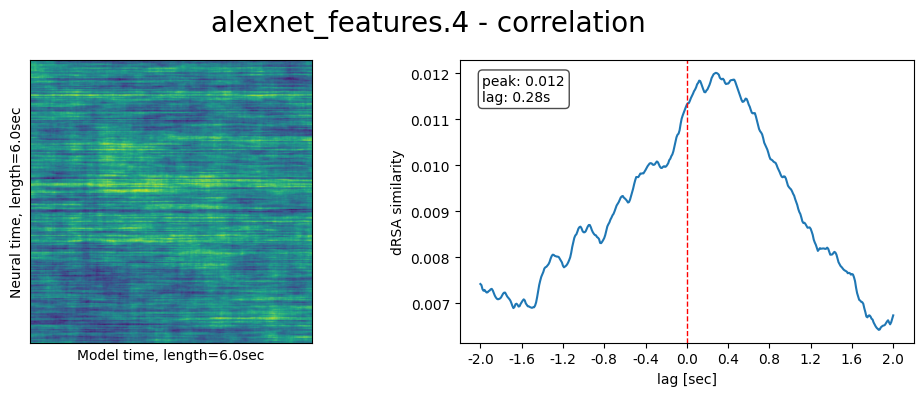

In [15]:
plot_rsa(tot_rsa, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)

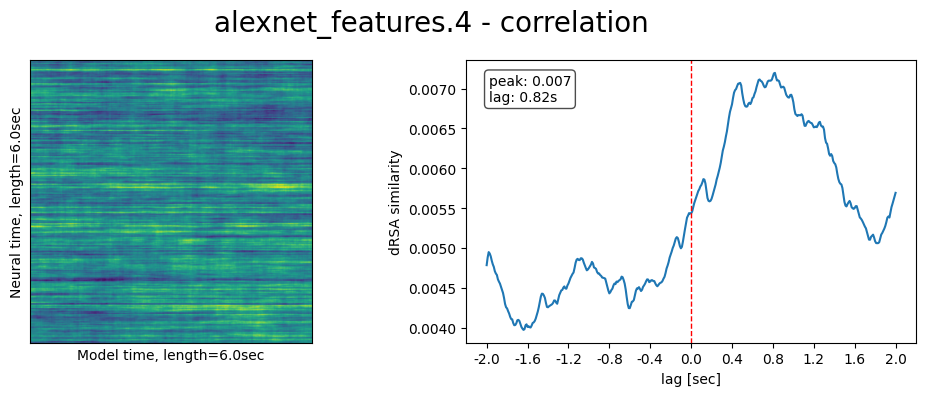

In [10]:
plot_rsa(tot_rsa, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)

In [11]:
tot_II = subsampling(neu, mod, cfg.time_points, cfg.iterations_n, cfg.pseudotrials_n, subsampling_II, *(cfg.RDM_metric, cfg.RDM_metric),**{"k": 20})

14:30:54 - starting iteration 0 of 99 
14:31:21 - starting iteration 10 of 99 
14:31:48 - starting iteration 20 of 99 
14:32:14 - starting iteration 30 of 99 
14:32:41 - starting iteration 40 of 99 
14:33:08 - starting iteration 50 of 99 
14:33:35 - starting iteration 60 of 99 
14:34:02 - starting iteration 70 of 99 
14:34:28 - starting iteration 80 of 99 
14:34:55 - starting iteration 90 of 99 


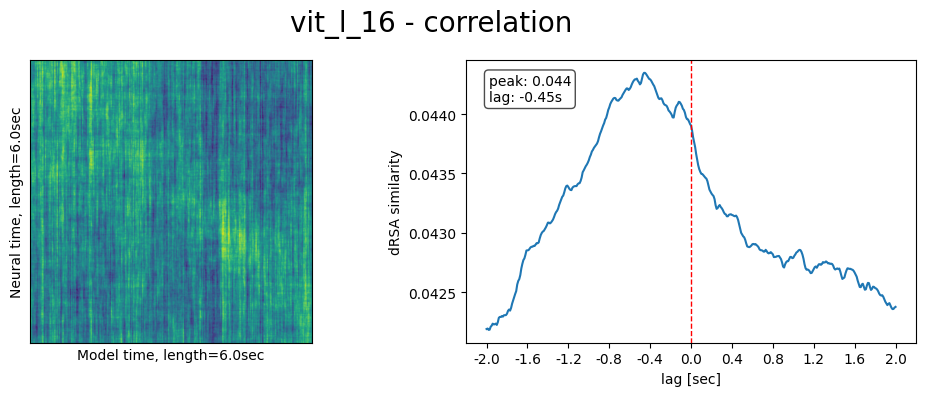

In [12]:
plot_rsa(1 -tot_II, cfg.neu_fs, cfg.max_lag, f"{cfg.model_name} - {cfg.RDM_metric}", tick_step=40)

In [ ]:
gaze_to_regr_out = []
for i_run in range(1,4):    
    run_gaze, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
    run_gaze.resample(cfg.neu_fs)
    gaze_to_regr_out.append(TimeSeries(run_gaze[:len_mod[i_run-1]],cfg.neu_fs))
    # end if cfg.regr_out_eyes:
# end for i_run in range(1,4)

tot_rsa_all_layers = []
for l in layers:
    try:
        print_wise(f"starting {l}")
        mod = []
        for i_run in range(1,4):
            model_filename = save_ANN_features(paths, f"{cfg.model_name}_{l}", cfg.sub_num, i_run + 3*cfg.repetition, cfg.sq_side, cfg.mod_fs,  1000,  'all')
            with h5py.File(model_filename, "r") as f:
                run_mod = f['vecrep'][:]
            # end with h5py.File(model_filename, "r") as f:
            run_mod = TimeSeries(run_mod, cfg.mod_fs)
            run_mod.resample(cfg.neu_fs)
            len_mod.append(len(run_mod)) 
            dyn_regr_obj = dyn_linear_encoding('lr', 'same', None)
            x_regress_out = dyn_regr_obj.pointwise_regress_out(gaze_to_regr_out[i_run-1], run_mod, regression_type=None)
            print(x_regress_out.shape)
            mod.append(x_regress_out[:])
        # end for i_run in range(1,4):
        mod = TimeSeries(np.concatenate(mod, axis=1), cfg.neu_fs)
        # neu = []
        # for i_run in range(1,4):
        #     run_neu, labels = load_meg_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.sensors_group, cfg.neu_fs)
        #     neu.append(run_neu[:len_mod[i_run-1]])
        # # end for i_run in range(1,4):
        # neu = TimeSeries(np.concatenate(neu, axis=1), cfg.neu_fs)
        tot_rsa = subsampling(neu, mod, cfg.time_points, cfg.iterations_n, cfg.pseudotrials_n, subsampling_RSA, *(cfg.RDM_metric, cfg.RDM_metric),)
        tot_rsa_all_layers.append(tot_rsa)
    except FileNotFoundError:
        print_wise(f"{l} not found")
os.system('afplay /System/Library/Sounds/Ping.aiff')

17:19:10 - starting blocks.0.mlp.fc2
<bound method TimeSeries.shape of <useful_stuff.general_utils.utils.TimeSeries object at 0x138281430>>
<bound method TimeSeries.shape of <useful_stuff.general_utils.utils.TimeSeries object at 0x13f7c9eb0>>


KeyboardInterrupt: 

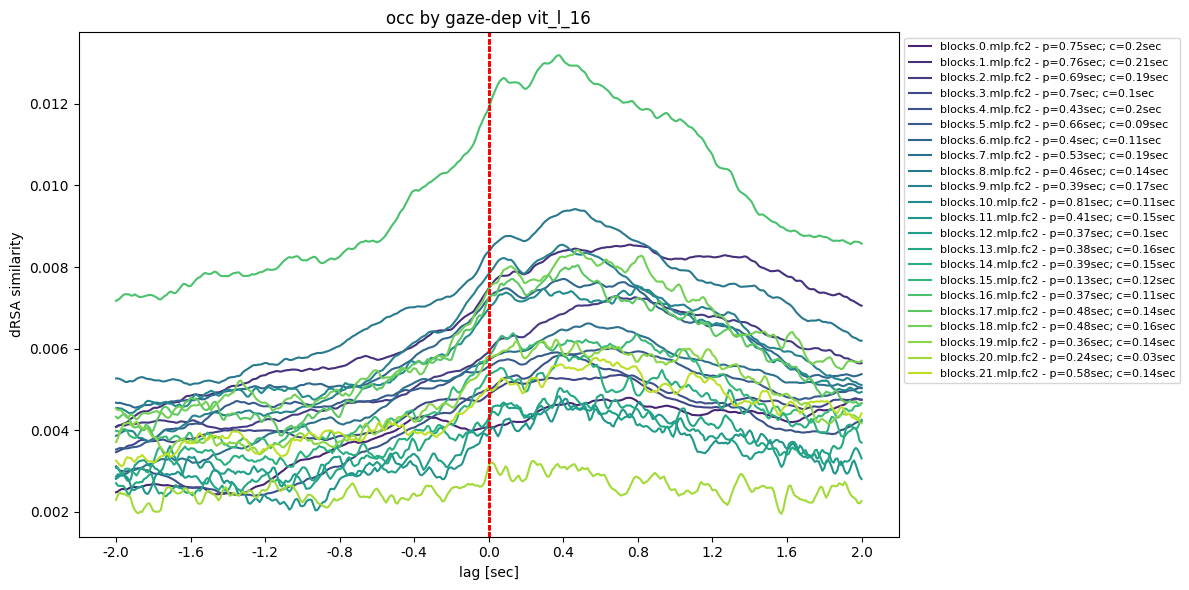

In [23]:
from useful_stuff.general_utils.plots import truncate_colormap
max_lag = cfg.max_lag
tick_step = 40
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(tot_rsa_all_layers)))
peaks = []
centroids = []
lagplots = []
plt.figure(figsize=(12, 6))
for idx, rsa in enumerate(tot_rsa_all_layers):
    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / cfg.neu_fs, 2)
    ticks += max_lag

    # --- lag plot ---
    lagplot = get_lagplot(rsa, max_lag=max_lag)
    lagplots.append(lagplot)
    # --- compute peak ---
    peak_idx = np.argmax(lagplot)
    lags = np.arange(-max_lag, max_lag + 1)

    weights = lagplot.copy()
    weights[weights < 0] = 0  # optional but recommended

    centroid = np.sum(lags * weights) / np.sum(weights)
    centroid_lag = np.round(centroid / cfg.neu_fs, 2)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / cfg.neu_fs  # convert to seconds
    peaks.append(peak_lag)
    centroids.append(centroid_lag)
    plt.plot(lagplot, label=f"{layers[idx]} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[idx])
    plt.ylabel("dRSA similarity")
    plt.xlabel("lag [sec]")
    plt.xticks(ticks, ticks_labels)
    plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)

plt.title(f"{cfg.sensors_group} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
lps = np.stack(lagplots, 0)

In [11]:
def compute_derivative(array, axis=-1):
    """
    Compute numerical derivative along a specified axis.
    
    Parameters:
    -----------
    array : np.ndarray
        Input array (2D or higher)
    axis : int
        Axis along which to compute derivative (default: -1, last axis)
    
    Returns:
    --------
    np.ndarray
        Derivative array (one element shorter along the specified axis)
    """
    return np.diff(array, axis=axis)

def smooth_curve(array, window_size=5):
    """
    Smooth a 1D curve or each row of a 2D array along the second dimension.

    Parameters:
    -----------
    array : np.ndarray
        1D array or 2D array of shape (n_samples, n_points)
    window_size : int
        Size of the moving-average window

    Returns:
    --------
    np.ndarray
        Smoothed array with the same shape as input
    """
    kernel = np.ones(window_size) / window_size

    if array.ndim == 1:
        return np.convolve(array, kernel, mode="same")

    return np.apply_along_axis(lambda x: np.convolve(x, kernel, mode="same"), axis=1, arr=array)

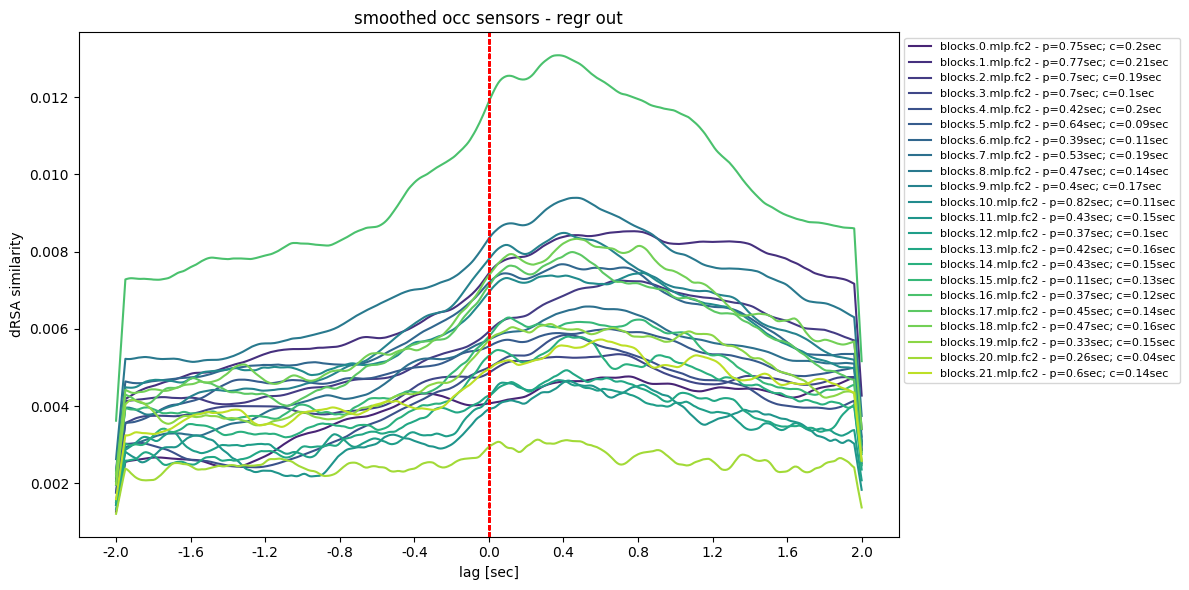

In [24]:
sm_lps = smooth_curve(lps, window_size=10)
sm_peaks = []
sm_centroids = []
plt.figure(figsize=(12, 6))
for i_layer in range(sm_lps.shape[0]):
    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / cfg.neu_fs, 2)
    ticks += max_lag

    lagplot = sm_lps[i_layer, :]
    # --- compute peak ---
    peak_idx = np.argmax(lagplot)
    lags = np.arange(-max_lag, max_lag + 1)

    weights = lagplot.copy()
    weights[weights < 0] = 0  # optional but recommended

    centroid = np.sum(lags * weights) / np.sum(weights)
    centroid_lag = np.round(centroid / cfg.neu_fs, 2)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / cfg.neu_fs  # convert to seconds
    sm_peaks.append(peak_lag)
    sm_centroids.append(centroid_lag)
    plt.plot(lagplot, label=f"{layers[i_layer]} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[i_layer])
    plt.ylabel("dRSA similarity")
    plt.xlabel("lag [sec]")
    plt.xticks(ticks, ticks_labels)
    plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)

plt.title(f"smoothed {cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()


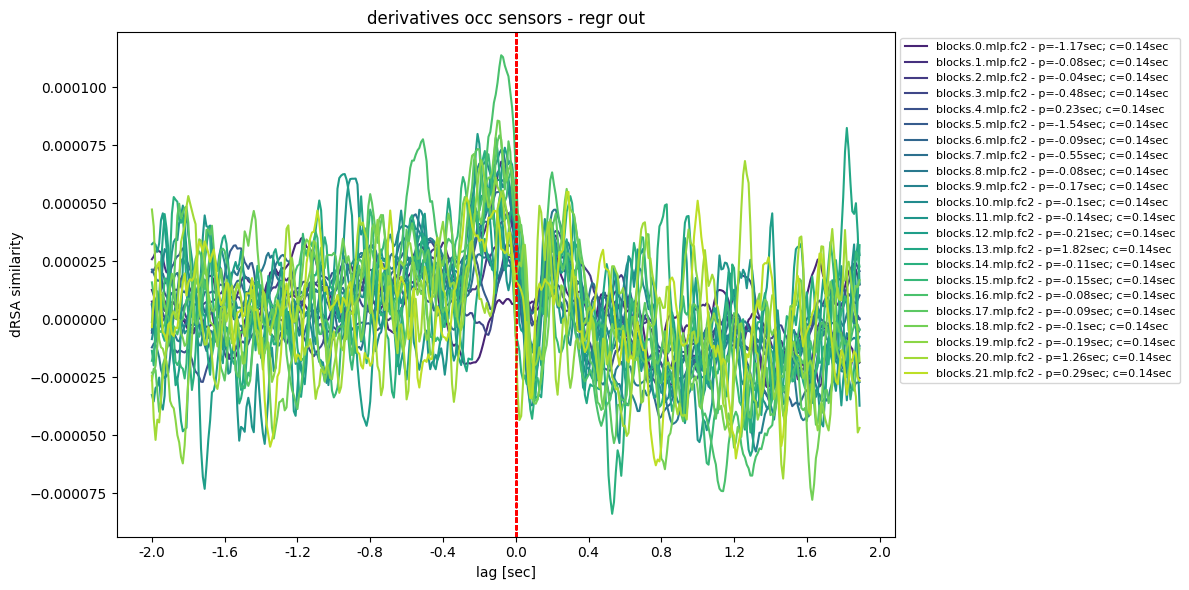

In [25]:
d_peaks = []
d_centroids = []
plt.figure(figsize=(12, 6))
d_lps = compute_derivative(sm_lps[:,2:-2])
d_lps = d_lps[:, 3:-3]
for i_layer in range(d_lps.shape[0]):
    # ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    # ticks_labels = np.round(ticks / cfg.neu_fs, 2)
    # ticks += max_lag

    lagplot = d_lps[i_layer, :]
    # --- compute peak ---
    peak_idx = np.argmax(lagplot)
    lags = np.arange(-max_lag, max_lag + 1)

    weights = lagplot.copy()
    weights[weights < 0] = 0  # optional but recommended

    # centroid = np.sum(lags[1:] * weights) / np.sum(weights)
    # centroid_lag = np.round(centroid / cfg.neu_fs, 2)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / cfg.neu_fs  # convert to seconds
    d_peaks.append(peak_lag)
    # d_centroids.append(centroid_lag)
    plt.plot(lagplot, label=f"{layers[i_layer]} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[i_layer])
    plt.ylabel("dRSA similarity")
    plt.xlabel("lag [sec]")
    plt.xticks(ticks, ticks_labels)
    plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)

plt.title(f"derivatives {cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()


# TO DO compute the derivative and do the same softmax thing

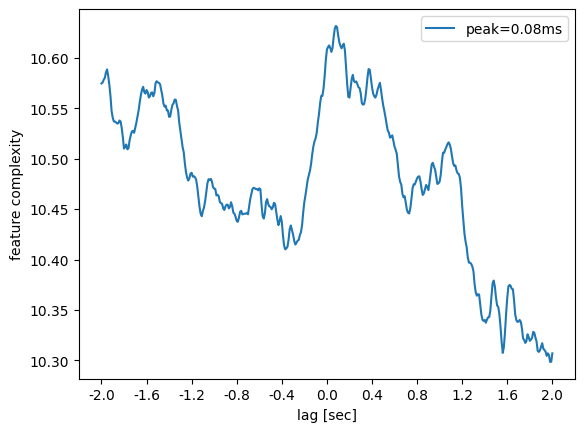

In [26]:
from useful_stuff.general_utils.utils import softmax


lps_1 = lps
softmax_lp = []
hardmax = []
temp = .01
for t in range(lps.shape[1]):
    softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0]))
    hardmax.append(np.argmax(lps[2:,t]))
plt.xticks(ticks, ticks_labels)
plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms")
# plt.plot(hardmax)
plt.xlabel("lag [sec]")
plt.ylabel("feature complexity")
plt.legend()


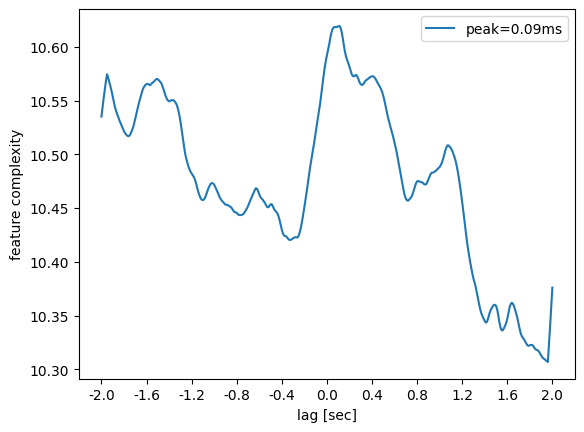

In [27]:
from useful_stuff.general_utils.utils import softmax

softmax_lp = []
hardmax = []
temp = .01
for t in range(lps.shape[1]):
    softmax_lp.append(softmax(sm_lps[:,t], T=temp)@np.arange(lps.shape[0]))
    hardmax.append(np.argmax(sm_lps[:,t]))
plt.xticks(ticks, ticks_labels)
plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp[2:-2])-cfg.max_lag)/cfg.neu_fs}ms")
# plt.plot(hardmax)
plt.xlabel("lag [sec]")
plt.ylabel("feature complexity")
plt.legend()


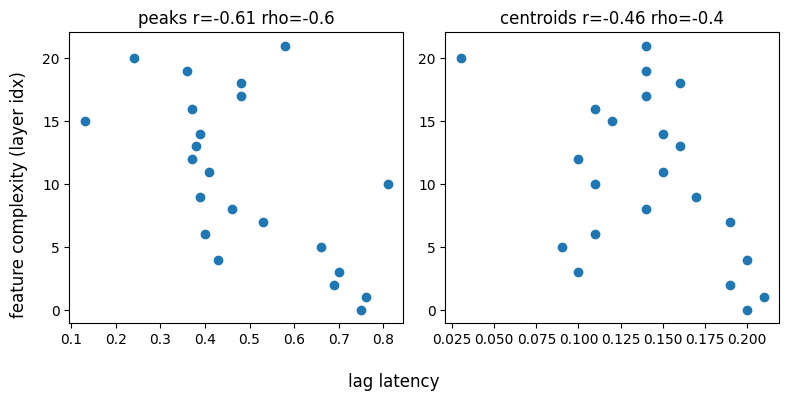

In [30]:
from useful_stuff.general_utils.utils import spearman
max_lag = cfg.max_lag
tick_step = 40
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

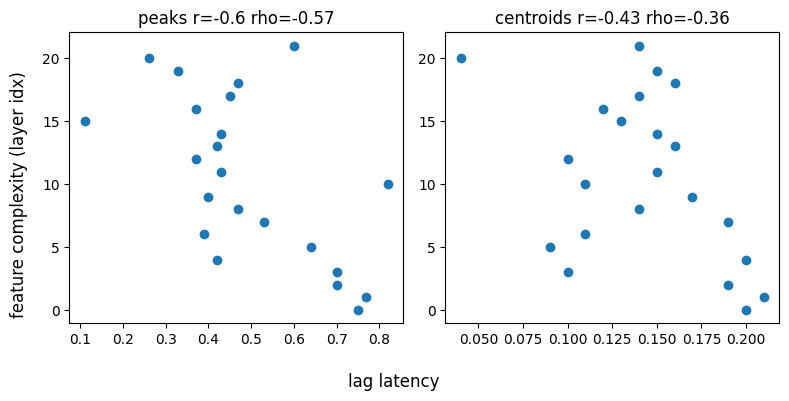

In [29]:
from useful_stuff.general_utils.utils import spearman
max_lag = cfg.max_lag
tick_step = 40
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(sm_peaks), np.arange(len(sm_peaks)))
rho = np.round(spearman(np.arange(len(sm_peaks)), np.array(sm_peaks)),2)
r = round(np.corrcoef(np.arange(len(sm_peaks)), np.array(sm_peaks))[0,1],2)
ax[0].set_title(f"peaks r={r} rho={rho}")
ax[1].scatter(sm_centroids, np.arange(len(sm_centroids)));
rho = np.round(spearman(np.arange(len(sm_peaks)), np.array(sm_centroids)), 2)
r = round(np.corrcoef(np.arange(len(sm_peaks)), np.array(sm_centroids))[0,1],2)
ax[1].set_title(f"centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()